In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Eco bin connect.csv")

print(df.head())

print(df.info())

         Date         Area Waste_Type Collection_Scheduled Collected_Status  \
0  2024-01-01  Apartment A    Organic                  Yes              Yes   
1  2024-01-01  Apartment B    Plastic                  Yes               No   
2  2024-01-02  Apartment A    Plastic                  Yes              Yes   
3  2024-01-02  Apartment C      Metal                   No               No   
4  2024-01-03  Apartment B    Organic                  Yes              Yes   

  Bin_Status Complaint_Raised  Scrap_Rate_per_kg  
0     Normal               No                  0  
1   Overflow              Yes                 12  
2     Normal               No                 15  
3   Overflow              Yes                 25  
4     Normal               No                  0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date        

Waste_Type
Organic    4
Plastic    4
Metal      3
E-waste    3
Name: count, dtype: int64


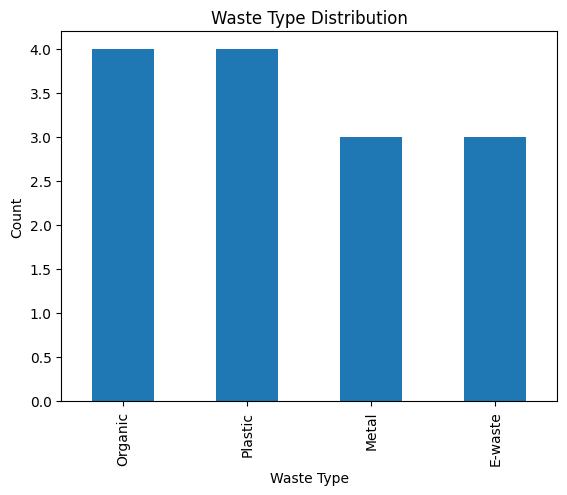

In [ ]:
print(df['Waste_Type'].value_counts())

df['Waste_Type'].value_counts().plot(kind='bar')
plt.title("Waste Type Distribution")
plt.xlabel("Waste Type")
plt.ylabel("Count")
plt.show()

Collected_Status
Yes    7
No     7
Name: count, dtype: int64


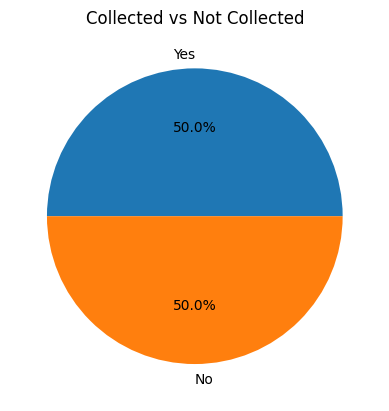

In [ ]:
print(df['Collected_Status'].value_counts())

df['Collected_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Collected vs Not Collected")
plt.ylabel("")
plt.show()

Bin_Status
Normal      7
Overflow    7
Name: count, dtype: int64


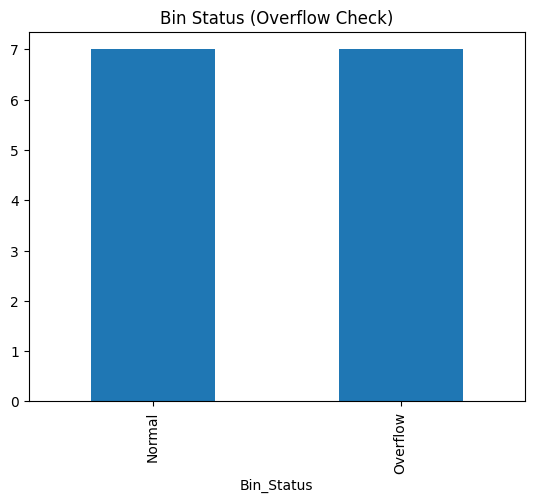

In [ ]:
print(df['Bin_Status'].value_counts())

df['Bin_Status'].value_counts().plot(kind='bar')
plt.title("Bin Status (Overflow Check)")
plt.show()

Complaint_Raised
No     7
Yes    7
Name: count, dtype: int64


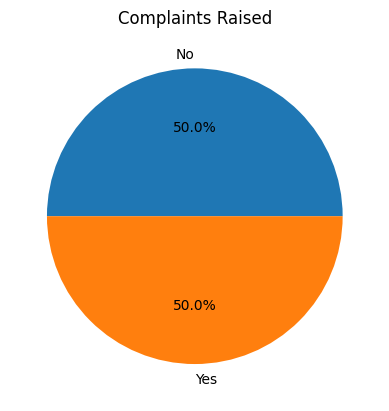

In [ ]:
print(df['Complaint_Raised'].value_counts())

df['Complaint_Raised'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Complaints Raised")
plt.ylabel("")
plt.show()

Collected_Status  No  Yes
Area                     
Apartment A        1    4
Apartment B        3    2
Apartment C        3    1


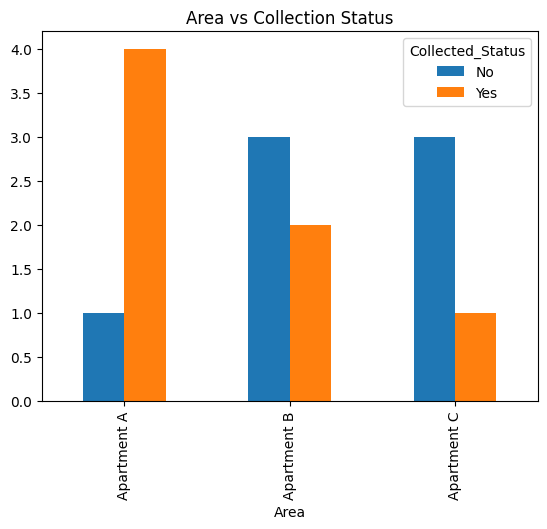

In [ ]:
area_data = df.groupby('Area')['Collected_Status'].value_counts().unstack()

print(area_data)

area_data.plot(kind='bar')
plt.title("Area vs Collection Status")
plt.show()

Collected_Status   No  Yes
Waste_Type                
E-waste           3.0  NaN
Metal             1.0  2.0
Organic           NaN  4.0
Plastic           3.0  1.0


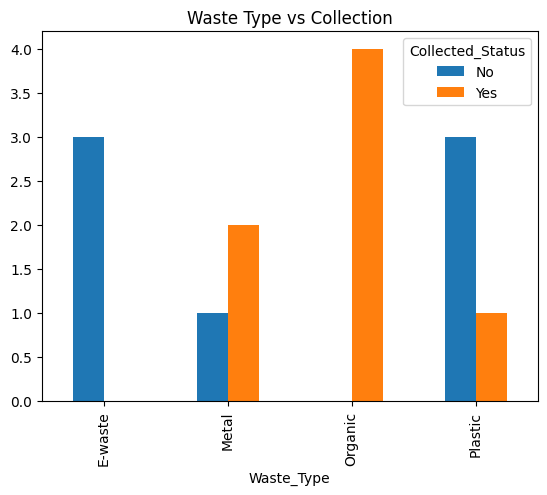

In [ ]:
waste_collection = df.groupby('Waste_Type')['Collected_Status'].value_counts().unstack()

print(waste_collection)

waste_collection.plot(kind='bar')
plt.title("Waste Type vs Collection")
plt.show()

Waste_Type
E-waste    31.000000
Metal      22.333333
Organic     0.000000
Plastic    12.750000
Name: Scrap_Rate_per_kg, dtype: float64


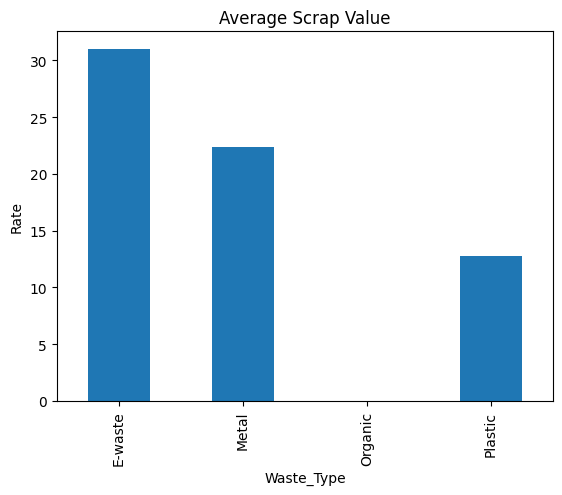

In [ ]:
scrap = df.groupby('Waste_Type')['Scrap_Rate_per_kg'].mean()

print(scrap)

scrap.plot(kind='bar')
plt.title("Average Scrap Value")
plt.ylabel("Rate")
plt.show()

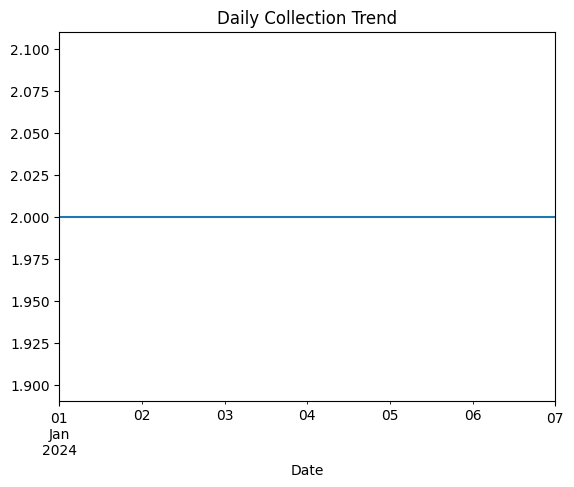

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df.groupby('Date')['Collected_Status'].count().plot()
plt.title("Daily Collection Trend")
plt.show()

In [ ]:
print("Most common waste:",
      df['Waste_Type'].value_counts().idxmax())

print("Most complaints area:",
      df[df['Complaint_Raised']=='Yes']['Area'].value_counts().idxmax())

print("Most missed waste:",
      df[df['Collected_Status']=='No']['Waste_Type'].value_counts().idxmax())

Most common waste: Organic
Most complaints area: Apartment B
Most missed waste: Plastic
